Open this notebook in Jupyter or upload it to Colab to run it.

# College Football Data Wrangling and Comparisons

## Overview
This notebook analyzes college football data from the 2016–2020 seasons. The data is distributed across multiple files, so the workflow combines file loading, cleaning, conference parsing, aggregation, and distribution comparisons.

Once we have cleaned and processed the data, we will put our statistics knowledge to good use by digging a little deeper than simple summary statistics.

Very rarely are data scientists handed a pristine data set ready for analysis. More often than not, quite a bit of work is required to clean and preprocess the data so that it's ready for analysis.

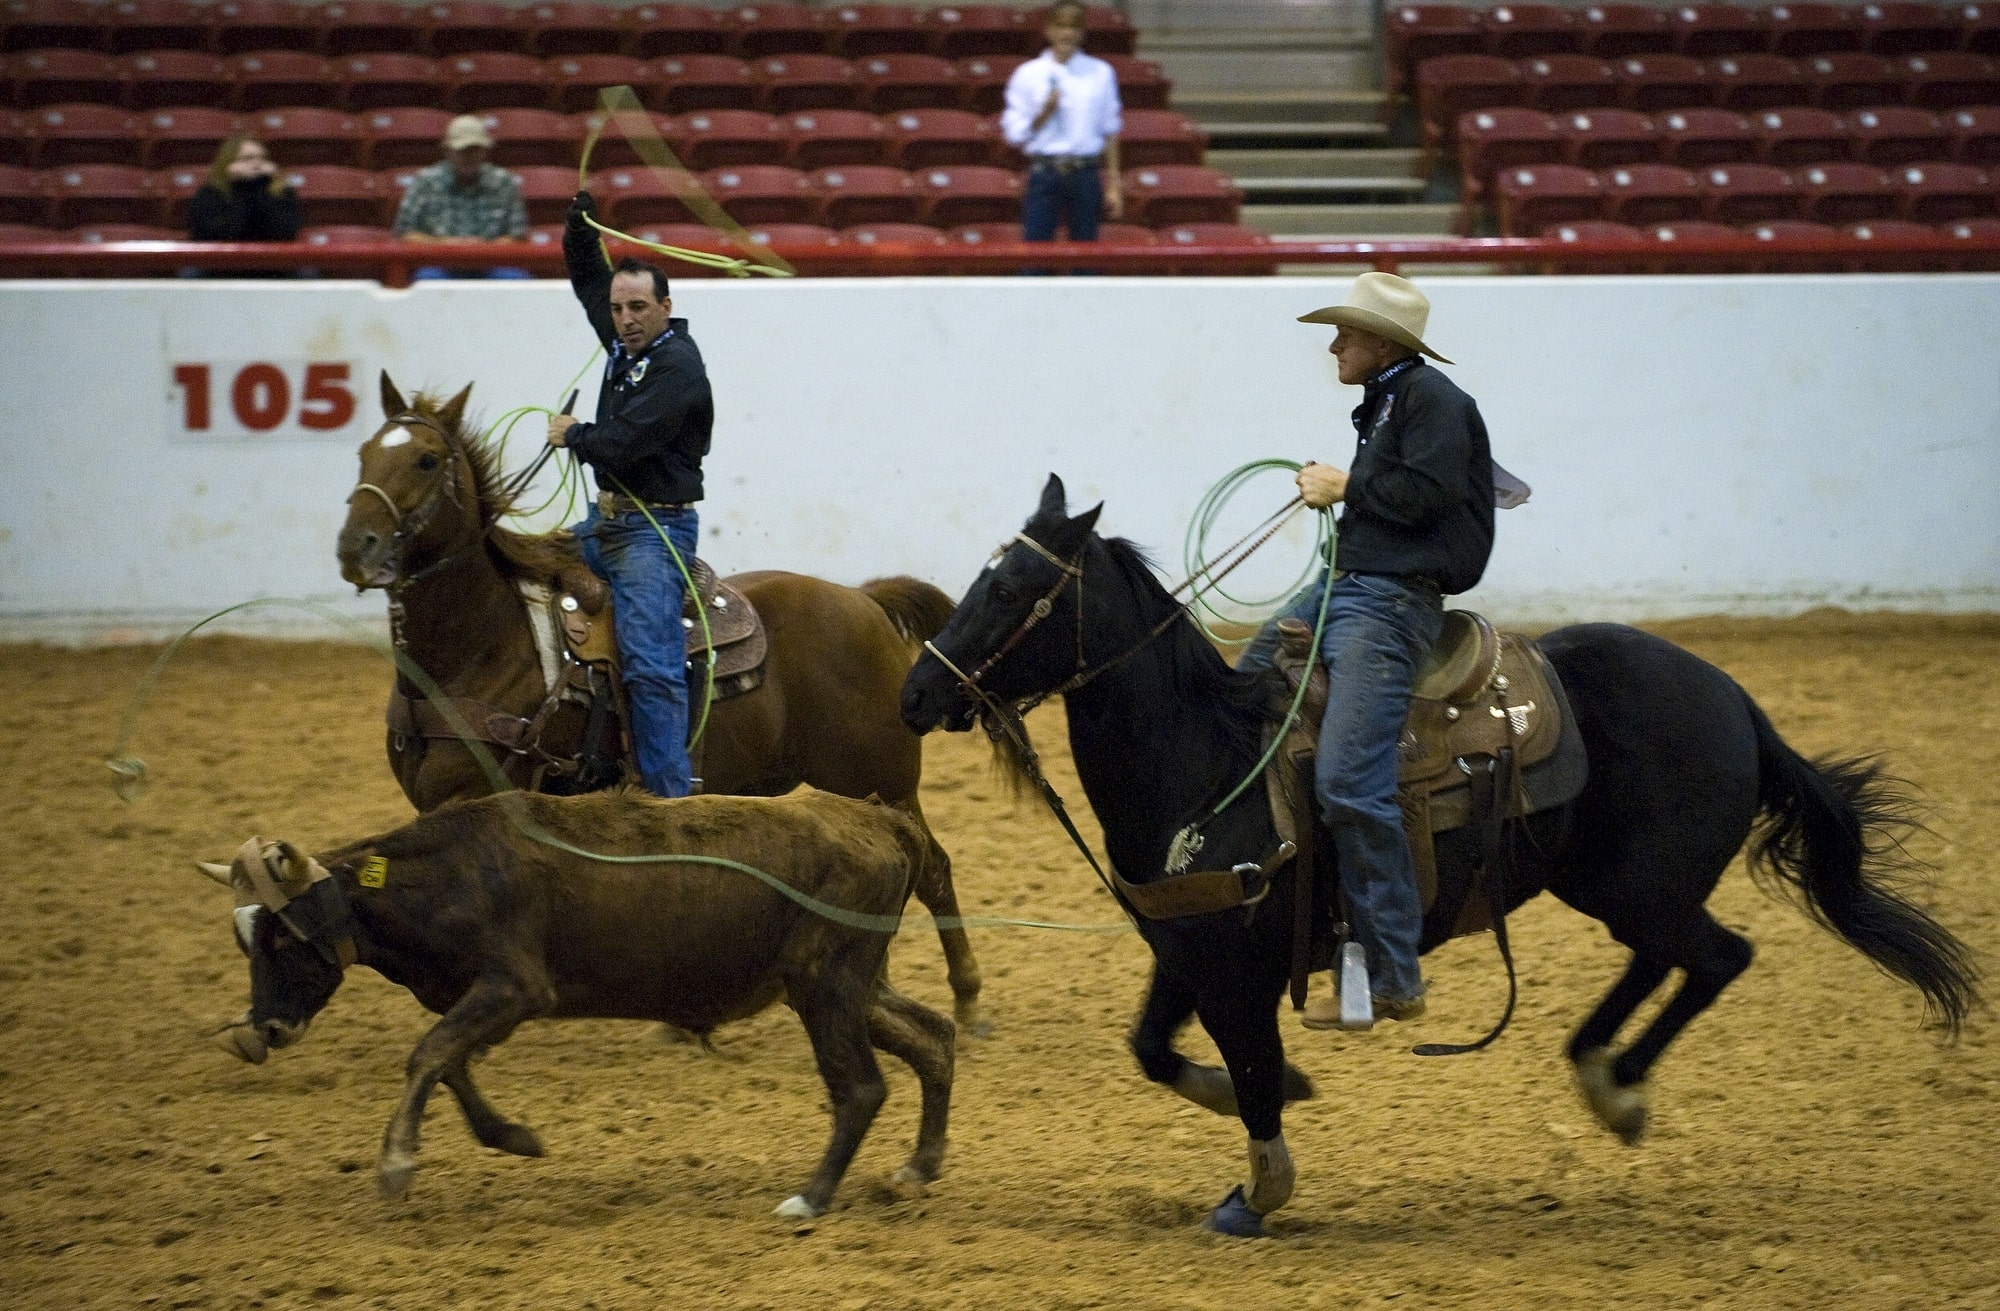

**Data wrangling**, also called **data cleaning**, **data remediation**, or **data munging**, refers to a variety of processes designed to transform raw data into more readily usable formats. The exact methods differ from project to project depending on the data you’re leveraging and the goal you’re trying to achieve.

Some examples of data wrangling include:

- Merging multiple data sources into a single dataset for analysis.

- Identifying gaps in data (for example, empty cells in a spreadsheet) and either filling or deleting them.

- Deleting data that’s either unnecessary or irrelevant to the project you’re working on.

- Identifying extreme outliers in data and either explaining the discrepancies or removing them.

#### Measures of Variability
We are very used to comparing point estimates. For example, in order to tell if one thing is better than the other, we may look at the average of each over time. Consider the following plot comparing the average of two groups, mu_0 and mu_1. 

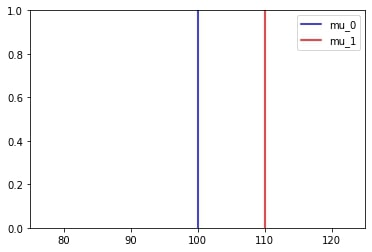

In this case, we might conclude that mu_1 is greater because it’s average is higher. However, we are ignoring an important aspect of the data: its variability. 

When we plot the **variability and the mean**, we observe the following plot:

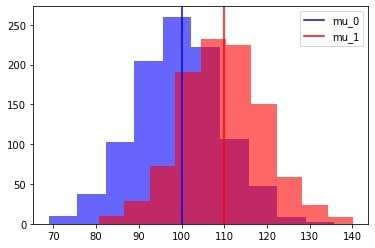

Now the distributions of mu_1 and mu_0 are so close that it’s difficult to say with certainty that mu_1 is better. For any random draw of mu_1, it’s roughly a 50-50 chance to actually be greater than a random draw of mu_0. 

Now suppose we observe the following plot:

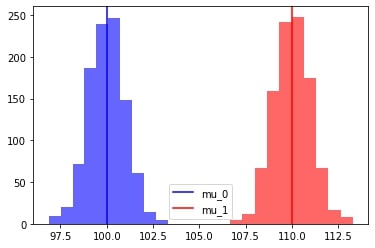

While the means are the same as before, the variability of the two distributions are now very different. We can say with a high degree of certainty that mu_1 is higher.

Keep this distinction in mind when comparing the football distributions.

### **Data:**
Data from the 2016, 2017, 2018, 2019, and 2020 college football seasons are also available on the course GitHub:

In [1]:
# Download the data by running this cell
!wget https://raw.githubusercontent.com/porterjenkins/cs180-intro-data-science/master/data/cfb16.csv
!wget https://raw.githubusercontent.com/porterjenkins/cs180-intro-data-science/master/data/cfb17.csv
!wget https://raw.githubusercontent.com/porterjenkins/cs180-intro-data-science/master/data/cfb18.csv
!wget https://raw.githubusercontent.com/porterjenkins/cs180-intro-data-science/master/data/cfb19.csv
!wget https://raw.githubusercontent.com/porterjenkins/cs180-intro-data-science/master/data/cfb20.csv

--2023-02-18 18:55:04--  https://raw.githubusercontent.com/porterjenkins/cs180-intro-data-science/master/data/cfb16.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 71618 (70K) [text/plain]
Saving to: ‘cfb16.csv.3’

cfb16.csv.3         100%[===================>]  69.94K  --.-KB/s    in 0.05s   

2023-02-18 18:55:04 (1.31 MB/s) - ‘cfb16.csv.3’ saved [71618/71618]

--2023-02-18 18:55:04--  https://raw.githubusercontent.com/porterjenkins/cs180-intro-data-science/master/data/cfb17.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length:

## Exercise 1: Yearly Counts

### Exercise Question
Read in the files, and add a year column to each file (from the original .csv file name).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Write your code to read in the files and add the year values from each csv:
cfb16 = pd.read_csv('cfb16.csv')
cfb17 = pd.read_csv('cfb17.csv')
cfb18 = pd.read_csv('cfb18.csv')
cfb19 = pd.read_csv('cfb19.csv')
cfb20 = pd.read_csv('cfb20.csv')

In [4]:
cfb16['Year'] = 2016
cfb17['Year'] = 2017
cfb18['Year'] = 2018
cfb19['Year'] = 2019
cfb20['Year'] = 2020

## Exercise 2: Data Aggregation

### Exercise Question
Combine every file into a single dataframe.

In [5]:
# Write your code to combine all of the csvs into one dataframe here
frames = [cfb16, cfb17, cfb18, cfb19, cfb20]
cfb_combined = pd.concat(frames)
cfb_combined.reset_index(inplace=True)
cfb_combined

,index,Team,Games,Win,Loss,Off.Rank,Off.Plays,Off.Yards,Off.Yards.Play,Off.TDs,...,Turnover.Rank,Fumbles.Recovered,Opponents.Intercepted,Turnovers.Gain,Fumbles.Lost,Interceptions.Thrown.y,Turnovers.Lost,Turnover.Margin,Avg.Turnover.Margin.per.Game,Year
0,0,Akron (MAC),12,5,7,84,776,4649,5.99,38,...,114,6,8,14,8,14,22,-8,-0.67,2016
1,1,Alabama (SEC),15,14,1,34,1056,6829,6.47,59,...,17,13,16,29,10,9,19,10,0.67,2016
2,2,Appalachian St. (Sun Belt),13,10,3,52,912,5589,6.13,45,...,18,1,20,21,5,8,13,8,0.62,2016
3,3,Arizona (Pac-12),12,3,9,67,815,4957,6.08,39,...,112,6,8,14,9,12,21,-7,-0.58,2016
4,4,Arizona St. (Pac-12),12,5,7,81,900,4689,5.21,43,...,93,8,9,17,7,14,21,-4,-0.33,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
626,122,West Virginia (Big 12),9,5,4,42,690,3804,5.51,28,...,42,2,10,12,6,3,9,3,0.33,2020
627,123,Western Ky. (C-USA),11,5,6,120,699,3200,4.58,21,...,83,4,5,9,10,2,12,-3,-0.27,2020
628,124,Western Mich. (MAC),6,4,2,15,392,2878,7.34,32,...,98,1,2,3,4,2,6,-3,-0.50,2020
629,125,Wisconsin (Big Ten),6,3,3,93,431,2153,5.00,17,...,98,4,4,8,5,6,11,-3,-0.50,2020


## Exercise 3: Conference Search

### Exercise Question
Create a `conference` field by parsing the `team` column.



Example: 

| Team | Conference |
| --- | --- |
| Penn State University (Big Ten) | Big Ten |

In [6]:
# Write your code to parse the conference from the team name:
cfb_combined['Conference'] = np.nan

def parser(row):
    pre = row['Team']
    pre = pre.replace('(','@(')
    pre = pre.replace(')', ')@')
    split = pre.split('@')
    parsed = ''
    for i in split:
        if i.startswith('(') and i.endswith(')'):
            parsed = i[1:-1]
    return parsed

In [7]:
for index, row in cfb_combined.iterrows():
    to_insert = parser(row)
    cfb_combined.at[index, 'Conference'] = to_insert

cfb_combined.head()

,index,Team,Games,Win,Loss,Off.Rank,Off.Plays,Off.Yards,Off.Yards.Play,Off.TDs,...,Fumbles.Recovered,Opponents.Intercepted,Turnovers.Gain,Fumbles.Lost,Interceptions.Thrown.y,Turnovers.Lost,Turnover.Margin,Avg.Turnover.Margin.per.Game,Year,Conference
0,0,Akron (MAC),12,5,7,84,776,4649,5.99,38,...,6,8,14,8,14,22,-8,-0.67,2016,MAC
1,1,Alabama (SEC),15,14,1,34,1056,6829,6.47,59,...,13,16,29,10,9,19,10,0.67,2016,SEC
2,2,Appalachian St. (Sun Belt),13,10,3,52,912,5589,6.13,45,...,1,20,21,5,8,13,8,0.62,2016,Sun Belt
3,3,Arizona (Pac-12),12,3,9,67,815,4957,6.08,39,...,6,8,14,9,12,21,-7,-0.58,2016,Pac-12
4,4,Arizona St. (Pac-12),12,5,7,81,900,4689,5.21,43,...,8,9,17,7,14,21,-4,-0.33,2016,Pac-12


## Exercise 4: Big Ten Vs. South Eastern

### Exercise Question 4a: Offense
- Is there a statistical difference between the Big Ten Conference and the South Eastern Conference in terms of `Off.Yards.per.Game`? Use a [seaborn KDE]("https://seaborn.pydata.org/generated/seaborn.kdeplot.html") plot to create a figure. Comment on the difference in means and the overlap of distributions. 

- Do the same as above for `Off.TDs`.

In [8]:
# Write the code for the statistical differences for Off.Yards.per.Game:
bigt_vs_sec = cfb_combined.loc[(cfb_combined['Conference'] == 'Big Ten') | (cfb_combined['Conference'] == 'SEC')]
bigt = bigt_vs_sec.loc[(bigt_vs_sec['Conference'] == 'Big Ten')]
sec = bigt_vs_sec.loc[(bigt_vs_sec['Conference'] == 'SEC')]

sec_mean = sec['Off.Yards.per.Game'].mean()
bigt_mean = bigt['Off.Yards.per.Game'].mean()

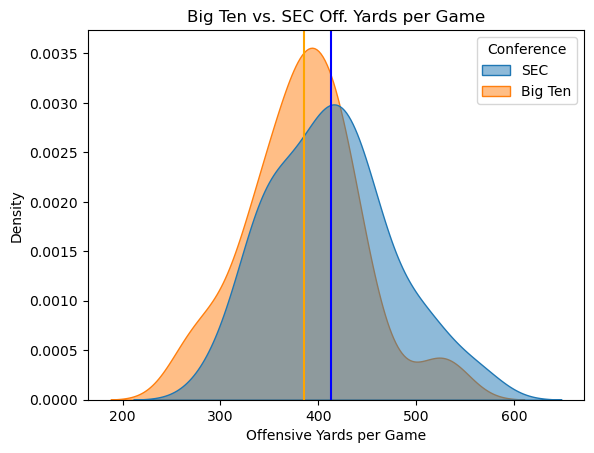

In [9]:
plot = sns.kdeplot(data = bigt_vs_sec, x = 'Off.Yards.per.Game', hue = 'Conference', fill = True, alpha = 0.5)
plot.set_title('Big Ten vs. SEC Off. Yards per Game')
plot.set_xlabel('Offensive Yards per Game')
plot.axvline(x = sec_mean, color = 'blue')
plot.axvline(x = bigt_mean, color = 'orange')
plt.show()

> The SEC mean for `Off.Yards.per.Game` is higher in this sample, but the KDE curves overlap substantially. A plot alone cannot establish statistical significance; a formal test and an effect-size estimate would be needed for that conclusion.

In [10]:
sec_mean = sec['Off.TDs'].mean()
bigt_mean = bigt['Off.TDs'].mean()

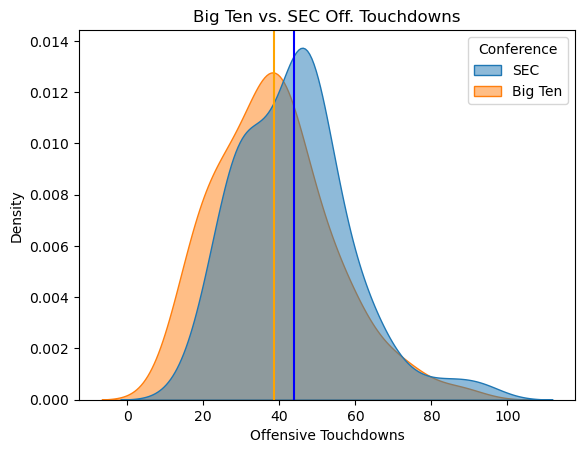

In [11]:
# Write the code for the statistical differences for Off.TDs:
plot = sns.kdeplot(data = bigt_vs_sec, x = 'Off.TDs', hue = 'Conference', fill = True, alpha = 0.5)
plot.set_title('Big Ten vs. SEC Off. Touchdowns')
plot.set_xlabel('Offensive Touchdowns')
plot.axvline(x = sec_mean, color = 'blue')
plot.axvline(x = bigt_mean, color = 'orange')
plt.show()

> The SEC mean for `Off.TDs` is higher in this sample, but the distributions overlap across much of their range. The visual comparison suggests a difference worth testing, not a definitive significance result.

### Exercise Question 4b: Defense
- Is there a statistical difference between the Big Ten Conference and the South Eastern Conference in terms  of `Points.Allowed`? Use a  [seaborn KDE]("https://seaborn.pydata.org/generated/seaborn.kdeplot.html") plot to create a figure.  Comment on the difference in means and the overlap of distributions. 

- Do the same as above for `Opp.Pass.Yds.Allowed` and `Opp.Rush.Yards.Alloweed`.



In [12]:
sec_mean = sec['Points.Allowed'].mean()
bigt_mean = bigt['Points.Allowed'].mean()

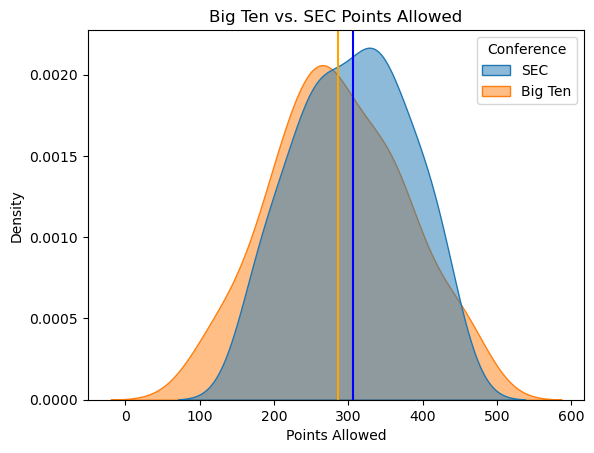

In [13]:
# Write the code for the statistical differences for Points.Allowed:
plot = sns.kdeplot(data = bigt_vs_sec, x = 'Points.Allowed', hue = 'Conference', fill = True, alpha = 0.5)
plot.set_title("Big Ten vs. SEC Points Allowed")
plot.set_xlabel("Points Allowed")
plot.axvline(x = sec_mean, color = 'blue')
plot.axvline(x = bigt_mean, color = 'orange')
plt.show()

> The SEC mean for `Points.Allowed` is higher in this sample, and the distributions overlap substantially. The KDE comparison alone is insufficient to claim that the conferences differ statistically.

In [14]:
sec_mean = sec['Opp.Pass.Yds.Allowed'].mean()
bigt_mean = bigt['Opp.Pass.Yds.Allowed'].mean()

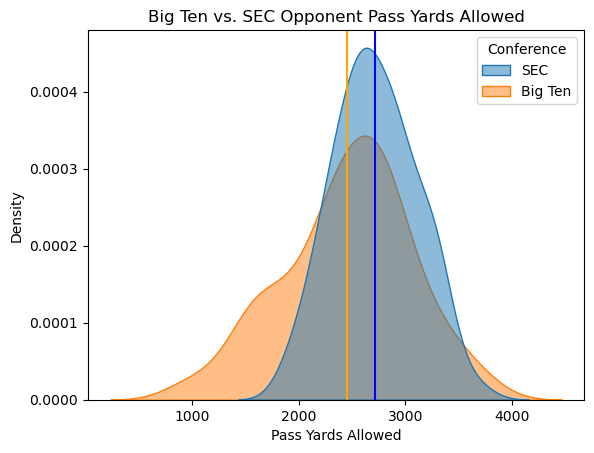

In [15]:
# Write the code for the statistical differences for Opp.Pass.Yds.Allowed:
plot = sns.kdeplot(data = bigt_vs_sec, x = 'Opp.Pass.Yds.Allowed', hue = 'Conference', fill = True, alpha = 0.5)
plot.set_title("Big Ten vs. SEC Opponent Pass Yards Allowed")
plot.set_xlabel("Pass Yards Allowed")
plot.axvline(x = sec_mean, color = 'blue')
plot.axvline(x = bigt_mean, color = 'orange')
plt.show()

> The SEC mean for `Opp.Pass.Yds.Allowed` is higher in this sample. The distributions overlap, and the Big Ten appears more left-skewed, but these plots do not by themselves establish a statistically significant conference difference.

In [16]:
sec_mean = sec['Opp.Rush.Yards.Alloweed'].mean()
bigt_mean = bigt['Opp.Rush.Yards.Alloweed'].mean()

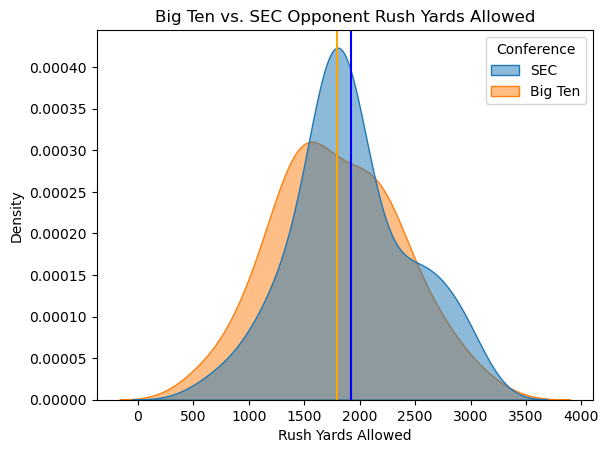

In [17]:
# Write the code for the statistical differences for Opp.Rush.Yards.Allowed:
plot = sns.kdeplot(data = bigt_vs_sec, x = 'Opp.Rush.Yards.Alloweed', hue = 'Conference', fill = True, alpha = 0.5)
plot.set_title("Big Ten vs. SEC Opponent Rush Yards Allowed")
plot.set_xlabel("Rush Yards Allowed")
plot.axvline(x = sec_mean, color = 'blue')
plot.axvline(x = bigt_mean, color = 'orange')
plt.show()

> The Big Ten mean for `Opp.Rush.Yards.Allowed` is slightly higher in this sample. The distributions overlap substantially, so the plot does not provide a clear basis for a significance claim.

## Exercise 5: Offense Statistics

### Exercise Question 5a: Offense
Is the offense changing over time? Create some plots showing the average offensive production over time (each year). Include an estimate of the variability in your figures. 

Comment on whether any trends you see are likely to be true or spurious.

Create a plot for the following metrics:
- `Off.Yards.per.Game`
- `Off.TDs`

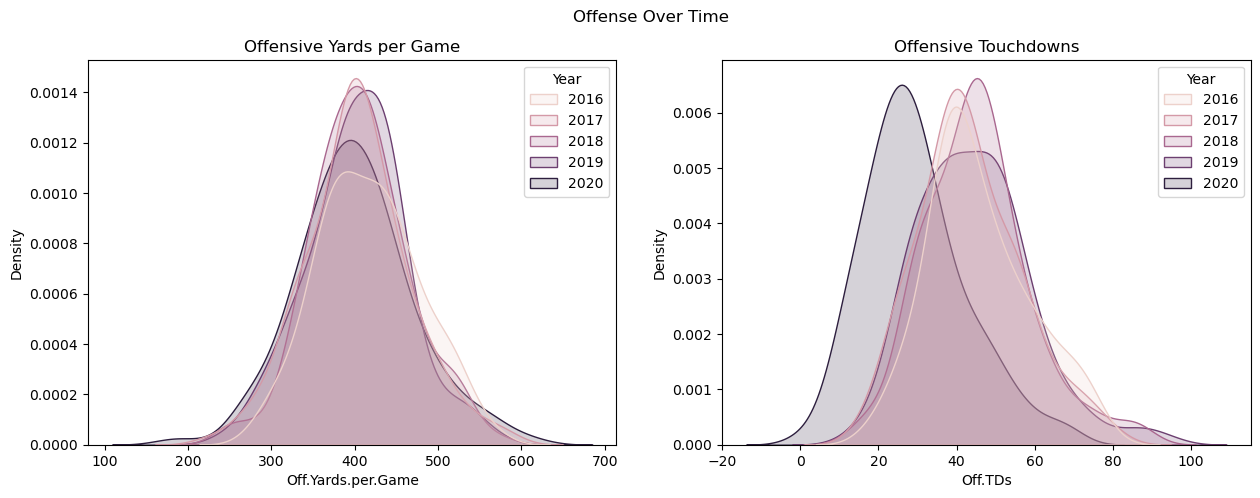

In [18]:
# Create a few plots showing how each metric changed over time:
fig, axes = plt.subplots(1,2, figsize = (15,5))
fig.suptitle('Offense Over Time')
sns.kdeplot(ax = axes[0], data = cfb_combined, x = 'Off.Yards.per.Game', hue = 'Year', fill = True, alpha = 0.2).title.set_text('Offensive Yards per Game')
sns.kdeplot(ax = axes[1], data = cfb_combined, x = 'Off.TDs', hue = 'Year', fill = True, alpha = 0.2).title.set_text('Offensive Touchdowns')
plt.show()

> `Off.Yards.per.Game` appears fairly stable across 2016–2020. `Off.TDs` is lower and less dispersed in 2020 than in the preceding seasons. This is a descriptive pattern, and 2020’s unusual season structure is a potential confounder rather than evidence of a general trend.

### Exercise Question 5b: Defense
Is the defense changing over time? Create some plots showing the average defensive production over time (each year). Include an estimate of the variability in your figures. 

Comment on whether any trends you see are likely to be true or spurious.

Create a plot for the following metrics:
- `Points.Allowed`
- `Opp.Pass.Yds.Allowed`
- `Opp.Rush.Yards.Allowed`

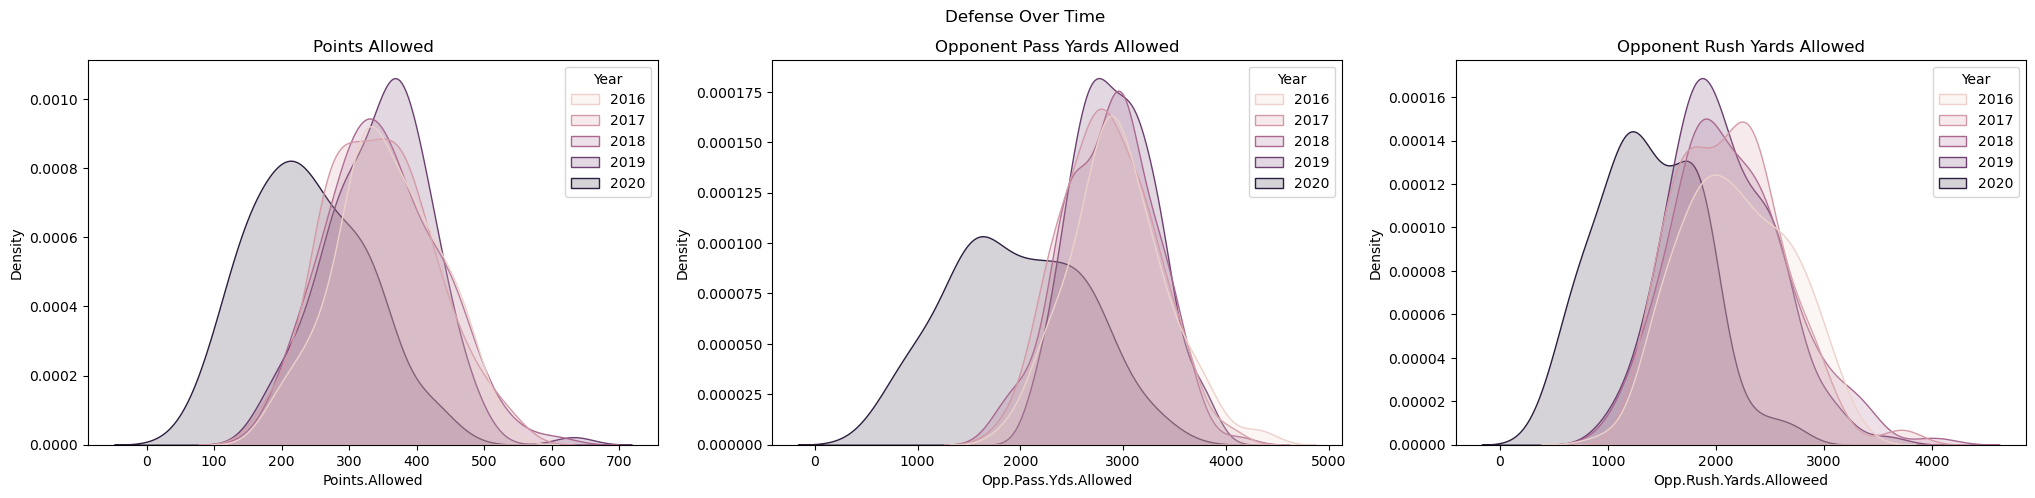

In [19]:
# Create a few plots showing how each metric changed over time:
fig, axes = plt.subplots(1,3, figsize = (25,5))
fig.suptitle('Defense Over Time')
sns.kdeplot(ax = axes[0], data = cfb_combined, x = 'Points.Allowed', fill = True, hue = 'Year', alpha = 0.2).title.set_text('Points Allowed')
sns.kdeplot(ax = axes[1], data = cfb_combined, x = 'Opp.Pass.Yds.Allowed', fill = True, hue = 'Year', alpha = 0.2).title.set_text('Opponent Pass Yards Allowed')
sns.kdeplot(ax = axes[2], data = cfb_combined, x = 'Opp.Rush.Yards.Alloweed', fill = True, hue = 'Year', alpha = 0.2).title.set_text('Opponent Rush Yards Allowed')
plt.show()

> For `Points.Allowed`, `Opp.Pass.Yds.Allowed`, and `Opp.Rush.Yards.Allowed`, the 2016–2019 distributions look broadly similar, while 2020 is shifted lower and has a narrower spread. Lower values are consistent with improved defensive outcomes, but the 2020 season’s unusual conditions mean this should not be interpreted as a causal improvement without additional analysis.